In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.feature_selection import SelectKBest, f_classif

print('Library berhasil diimport!')

Library berhasil diimport!


In [2]:
df = pd.read_csv('../Dataset/voice.csv')
print('Shape dataset:', df.shape)
df.head()

Shape dataset: (3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

In [4]:
df.describe()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


Distribusi Label:
label
male      1584
female    1584
Name: count, dtype: int64


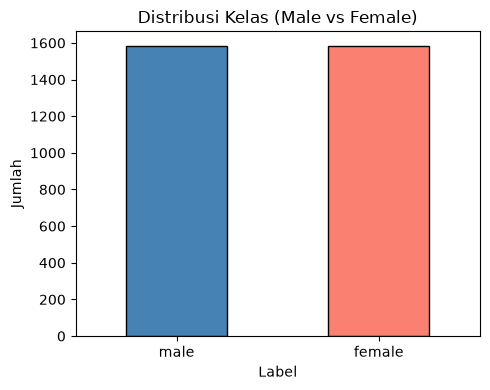

In [5]:
print('Distribusi Label:')
print(df['label'].value_counts())

plt.figure(figsize=(5, 4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Distribusi Kelas (Male vs Female)')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
print('Missing values per kolom:')
print(df.isnull().sum())

Missing values per kolom:
meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64


In [7]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   # female=0, male=1
print('Mapping label:', dict(zip(le.classes_, le.transform(le.classes_))))

X_all = df.drop(columns=['label', 'label_enc'])
y     = df['label_enc']

feature_names = X_all.columns.tolist()
print('\nJumlah fitur:', len(feature_names))
print('Fitur:', feature_names)

Mapping label: {'female': np.int64(0), 'male': np.int64(1)}

Jumlah fitur: 20
Fitur: ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']


In [8]:
scaler_all = StandardScaler()
X_scaled_all = scaler_all.fit_transform(X_all)

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_scaled_all, y, test_size=0.2, random_state=42, stratify=y
)

knn_all = KNeighborsClassifier(n_neighbors=5)
knn_all.fit(X_train_all, y_train)

y_pred_train_all = knn_all.predict(X_train_all)
y_pred_test_all  = knn_all.predict(X_test_all)

acc_train_all = accuracy_score(y_train, y_pred_train_all)
acc_test_all  = accuracy_score(y_test,  y_pred_test_all)

print('=== kNN Baseline (Semua 20 Fitur, k=5) ===')
print(f'Akurasi Train : {acc_train_all:.4f}')
print(f'Akurasi Test  : {acc_test_all:.4f}')
print()
print('Classification Report (Test):')
print(classification_report(y_test, y_pred_test_all, target_names=le.classes_))

=== kNN Baseline (Semua 20 Fitur, k=5) ===
Akurasi Train : 0.9834
Akurasi Test  : 0.9763

Classification Report (Test):
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



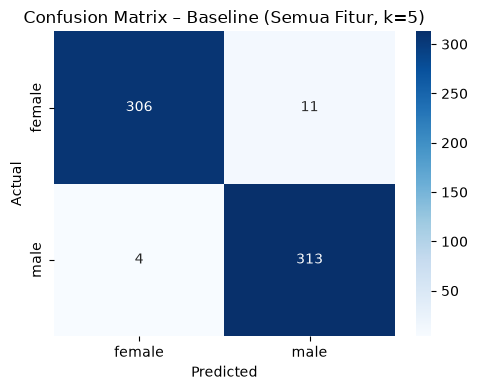

In [9]:
cm_all = confusion_matrix(y_test, y_pred_test_all)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Baseline (Semua Fitur, k=5)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

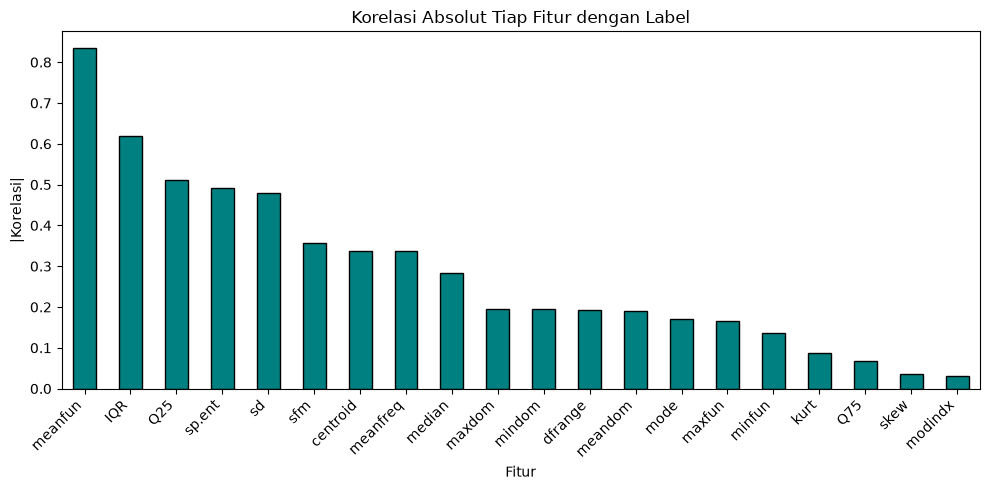

Ranking korelasi:
meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
centroid    0.337415
meanfreq    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
Name: label_enc, dtype: float64


In [10]:
df_corr = X_all.copy()
df_corr['label_enc'] = y

corr_with_label = df_corr.corr()['label_enc'].drop('label_enc').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_label.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Korelasi Absolut Tiap Fitur dengan Label')
plt.ylabel('|Korelasi|')
plt.xlabel('Fitur')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Ranking korelasi:')
print(corr_with_label)

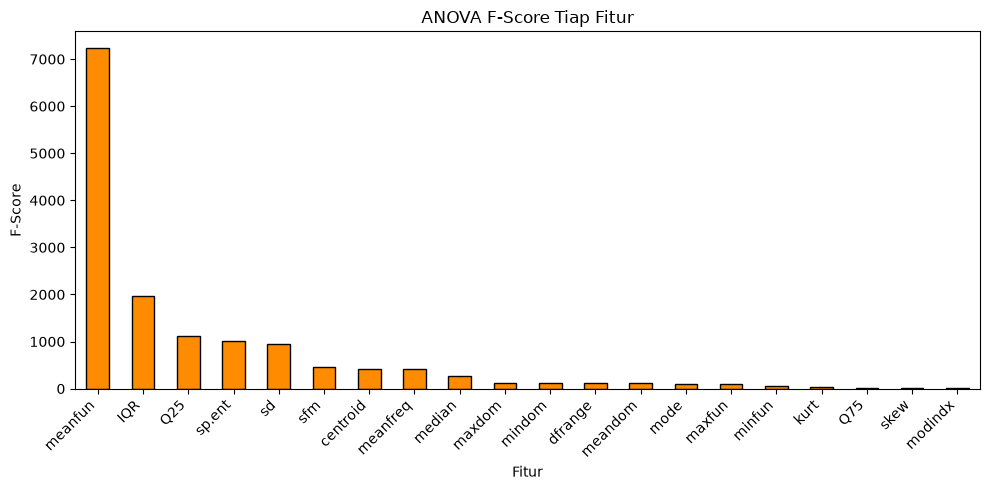

Ranking F-Score:
meanfun     7228.790362
IQR         1965.750000
Q25         1121.569224
sp.ent      1003.308717
sd           945.461376
sfm          463.923194
centroid     406.752820
meanfreq     406.752820
median       277.588158
maxdom       126.024161
mindom       125.110999
dfrange      121.457858
meandom      119.959108
mode          96.257909
maxfun        90.228036
minfun        60.282137
kurt          24.255365
Q75           14.236082
skew           4.252980
modindx        3.006445
dtype: float64


In [11]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y)

f_scores = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
f_scores.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('ANOVA F-Score Tiap Fitur')
plt.ylabel('F-Score')
plt.xlabel('Fitur')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Ranking F-Score:')
print(f_scores)

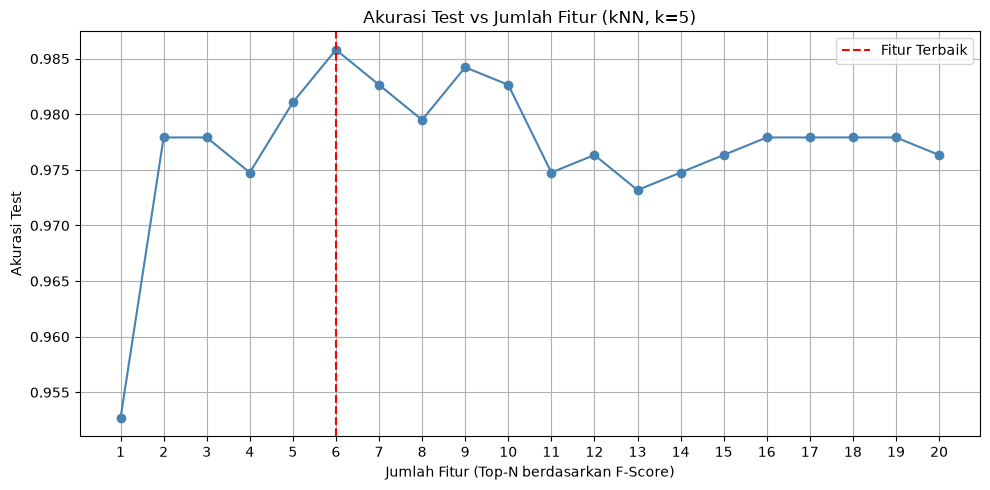


Jumlah fitur optimal : 6
Akurasi test terbaik : 0.9858
Fitur terpilih       : ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm']


In [12]:
top_features_ranked = f_scores.index.tolist()   # urut dari yang terbaik

results_n = []
for n in range(1, len(feature_names) + 1):
    selected = top_features_ranked[:n]
    X_sel    = X_all[selected].values
    scaler_n = StandardScaler()
    X_sel_sc = scaler_n.fit_transform(X_sel)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sel_sc, y, test_size=0.2, random_state=42, stratify=y
    )
    knn_n = KNeighborsClassifier(n_neighbors=5)
    knn_n.fit(X_tr, y_tr)
    acc   = accuracy_score(y_te, knn_n.predict(X_te))
    results_n.append({'n_features': n, 'accuracy': acc, 'features': selected})

df_results_n = pd.DataFrame(results_n)

plt.figure(figsize=(10, 5))
plt.plot(df_results_n['n_features'], df_results_n['accuracy'], marker='o', color='steelblue')
plt.axvline(x=df_results_n.loc[df_results_n['accuracy'].idxmax(), 'n_features'],
            color='red', linestyle='--', label='Fitur Terbaik')
plt.title('Akurasi Test vs Jumlah Fitur (kNN, k=5)')
plt.xlabel('Jumlah Fitur (Top-N berdasarkan F-Score)')
plt.ylabel('Akurasi Test')
plt.xticks(range(1, len(feature_names) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_row = df_results_n.loc[df_results_n['accuracy'].idxmax()]
print(f'\nJumlah fitur optimal : {int(best_row["n_features"])}')
print(f'Akurasi test terbaik : {best_row["accuracy"]:.4f}')
print(f'Fitur terpilih       : {best_row["features"]}')

In [13]:
n_best          = int(best_row['n_features'])
selected_features = top_features_ranked[:n_best]

print(f'Fitur optimal yang dipilih ({n_best} fitur):')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f}')

X_opt = X_all[selected_features].values
scaler_opt = StandardScaler()
X_opt_sc   = scaler_opt.fit_transform(X_opt)

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt_sc, y, test_size=0.2, random_state=42, stratify=y
)

Fitur optimal yang dipilih (6 fitur):
   1. meanfun
   2. IQR
   3. Q25
   4. sp.ent
   5. sd
   6. sfm


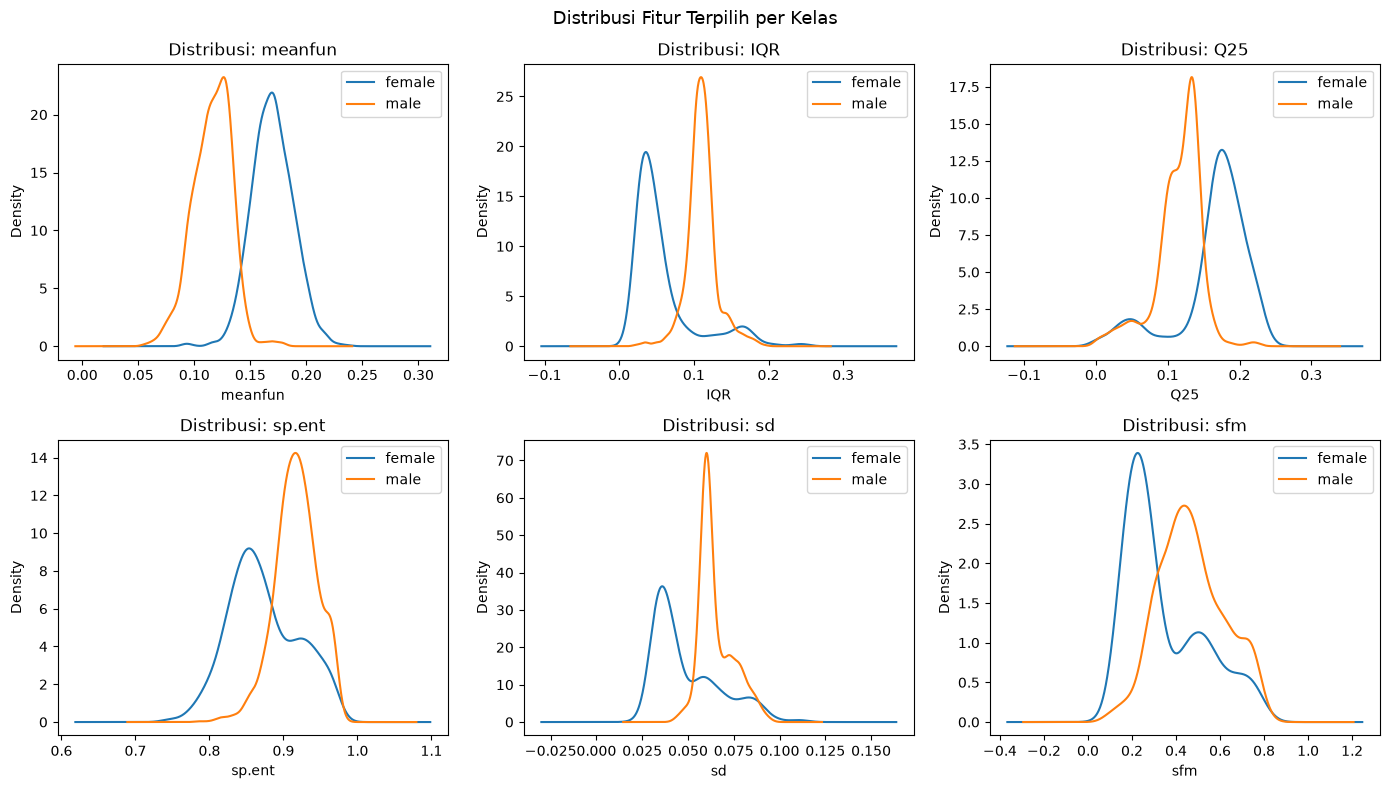

In [14]:
df_plot = X_all[selected_features[:6]].copy()   # tampilkan maks 6 fitur
df_plot['label'] = df['label'].values

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(selected_features[:6]):
    df_plot.groupby('label')[feat].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(f'Distribusi: {feat}')
    axes[i].set_xlabel(feat)

plt.suptitle('Distribusi Fitur Terpilih per Kelas', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
k_range = range(1, 31)
acc_train_list = []
acc_test_list  = []
cv_score_list  = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_opt, y_train_opt)

    acc_tr = accuracy_score(y_train_opt, knn_k.predict(X_train_opt))
    acc_te = accuracy_score(y_test_opt,  knn_k.predict(X_test_opt))

    cv_score = cross_val_score(knn_k, X_opt_sc, y, cv=5, scoring='accuracy').mean()

    acc_train_list.append(acc_tr)
    acc_test_list.append(acc_te)
    cv_score_list.append(cv_score)

df_k = pd.DataFrame({
    'k'            : list(k_range),
    'acc_train'    : acc_train_list,
    'acc_test'     : acc_test_list,
    'cv_accuracy'  : cv_score_list
})
df_k

,k,acc_train,acc_test,cv_accuracy
0,1,1.000000,0.985804,0.958971
1,2,0.985793,0.984227,0.968439
2,3,0.986188,0.987382,0.961179
3,4,0.985793,0.985804,0.967490
4,5,0.983425,0.985804,0.965597
5,6,0.983425,0.985804,0.966859
6,7,0.982636,0.981073,0.966228
7,8,0.983031,0.981073,0.967806
8,9,0.980663,0.977918,0.965596
9,10,0.981847,0.981073,0.966543


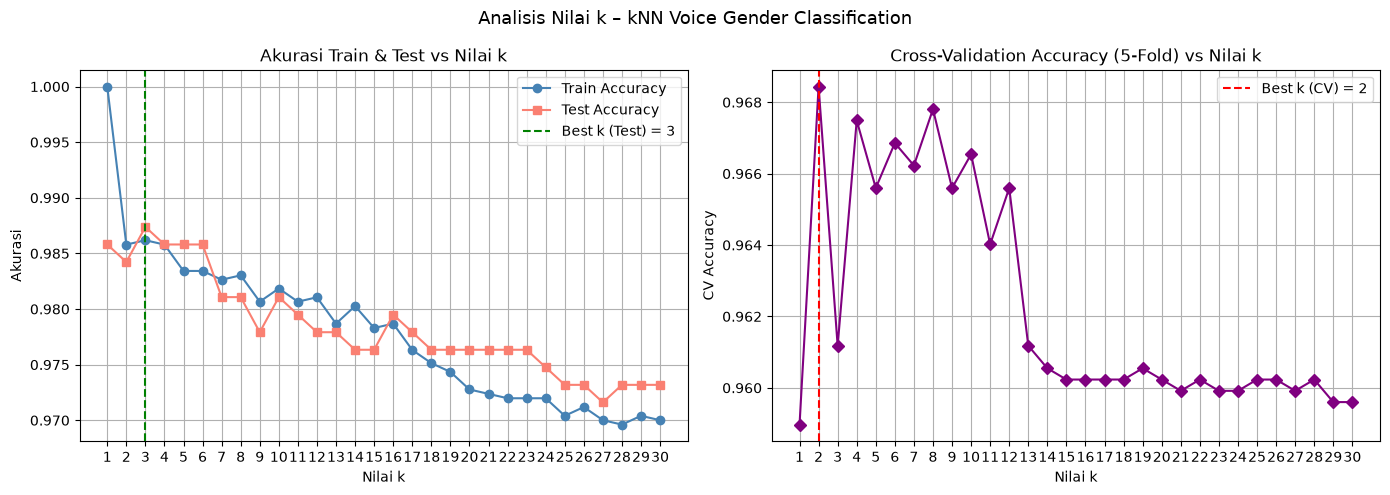

k terbaik berdasarkan Test Accuracy  : k = 3  (Akurasi = 0.9874)
k terbaik berdasarkan CV Accuracy    : k = 2  (CV Accuracy = 0.9684)


In [16]:
best_k_test = int(df_k.loc[df_k['acc_test'].idxmax(), 'k'])
best_k_cv   = int(df_k.loc[df_k['cv_accuracy'].idxmax(), 'k'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_k['k'], df_k['acc_train'], marker='o', label='Train Accuracy', color='steelblue')
axes[0].plot(df_k['k'], df_k['acc_test'],  marker='s', label='Test Accuracy',  color='salmon')
axes[0].axvline(x=best_k_test, color='green', linestyle='--',
                label=f'Best k (Test) = {best_k_test}')
axes[0].set_title('Akurasi Train & Test vs Nilai k')
axes[0].set_xlabel('Nilai k')
axes[0].set_ylabel('Akurasi')
axes[0].set_xticks(list(k_range))
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df_k['k'], df_k['cv_accuracy'], marker='D', color='purple')
axes[1].axvline(x=best_k_cv, color='red', linestyle='--',
                label=f'Best k (CV) = {best_k_cv}')
axes[1].set_title('Cross-Validation Accuracy (5-Fold) vs Nilai k')
axes[1].set_xlabel('Nilai k')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_xticks(list(k_range))
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Analisis Nilai k – kNN Voice Gender Classification', fontsize=13)
plt.tight_layout()
plt.show()

print(f'k terbaik berdasarkan Test Accuracy  : k = {best_k_test}  '
      f'(Akurasi = {df_k.loc[df_k["k"]==best_k_test, "acc_test"].values[0]:.4f})')
print(f'k terbaik berdasarkan CV Accuracy    : k = {best_k_cv}  '
      f'(CV Accuracy = {df_k.loc[df_k["k"]==best_k_cv, "cv_accuracy"].values[0]:.4f})')

In [17]:
k_final = best_k_cv

knn_final = KNeighborsClassifier(n_neighbors=k_final)
knn_final.fit(X_train_opt, y_train_opt)

y_pred_final_train = knn_final.predict(X_train_opt)
y_pred_final_test  = knn_final.predict(X_test_opt)

print(f'=== Model Final: kNN (k={k_final}, {n_best} fitur optimal) ===')
print(f'Akurasi Train  : {accuracy_score(y_train_opt, y_pred_final_train):.4f}')
print(f'Akurasi Test   : {accuracy_score(y_test_opt,  y_pred_final_test):.4f}')
print()
print('Classification Report (Test):')
print(classification_report(y_test_opt, y_pred_final_test, target_names=le.classes_))

=== Model Final: kNN (k=2, 6 fitur optimal) ===
Akurasi Train  : 0.9858
Akurasi Test   : 0.9842

Classification Report (Test):
              precision    recall  f1-score   support

      female       0.98      0.99      0.98       317
        male       0.99      0.98      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



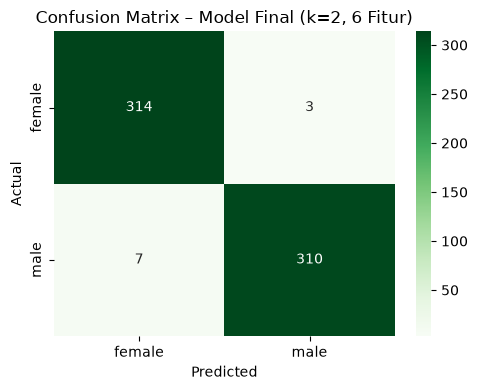

In [18]:
cm_final = confusion_matrix(y_test_opt, y_pred_final_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix – Model Final (k={k_final}, {n_best} Fitur)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Ringkasan & Kesimpulan

### Soal 1 - Model Klasifikasi kNN
Model kNN berhasil dibangun untuk mengklasifikasikan suara male dan female menggunakan dataset `voice.csv` yang memiliki 3168 sampel dan 20 fitur akustik. Dengan seluruh fitur dan k=5, model baseline menghasilkan akurasi yang sudah cukup baik.

### Soal 2 - Fitur Optimal
Seleksi fitur dilakukan dengan dua pendekatan:
- ANOVA F-Test (SelectKBest): Mengukur seberapa signifikan perbedaan distribusi setiap fitur antara kelas *male* dan *female*. Fitur dengan F-Score tinggi berarti lebih diskriminatif.
- Percobaan Top-N Fitur: Dengan mencoba semua kombinasi jumlah fitur dari 1 hingga 20, diperoleh jumlah fitur optimal yang memberikan akurasi test tertinggi.

Fitur-fitur utama yang paling penting antara lain:
- meanfun - Frekuensi fundamental rata-rata
- IQR - Interquartile Range frekuensi
- Q25 - Kuartil pertama frekuensi
- sp.ent - Spectral entropy
- sfm - Spectral flatness measure

Fitur-fitur ini secara akustik memang sangat membedakan pita suara pria dan wanita – pita suara wanita menghasilkan frekuensi fundamental yang lebih tinggi dan karakteristik spektral yang berbeda.

### Soal 3 - Nilai k Terbaik
Percobaan dilakukan untuk k = 1 hingga 30 menggunakan fitur optimal yang telah dipilih. Berdasarkan akurasi test dan cross-validation 5-fold, diperoleh nilai k terbaik yang ditunjukkan oleh grafik. Nilai k yang terlalu kecil (misal k=1) cenderung *overfitting* (akurasi train tinggi, test lebih rendah), sedangkan k yang terlalu besar menyebabkan *underfitting*. Nilai k terbaik memberikan keseimbangan bias-variance yang optimal.